In [1]:
import numpy as np

class Softmax:
    # Xavier initialization
    weight_init_factor = 1.

    def forward(self, x):
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

class Sigmoid:
    # Xavier initialization
    weight_init_factor = 1.

    def forward(self, x):
        return 1 / (1 + np.exp(-x))
    
    def derivative(self, x):
        s = self.forward(x)
        return s * (1 - s)


class ReLU:
    # He initialization
    weight_init_factor = np.sqrt(2)

    def forward(self, x):
        return np.maximum(0, x)
    
    def derivative(self, x):
        return (x > 0).astype(float)

In [ ]:
class Layer:
    def __init__(self, num_neurons: int, num_input_connections: int, activation_function, rng, alpha=0.05, beta_one=0.9, beta_two=0.999, epsilon = 1e-8):
        self.num_neurons = num_neurons
        self.activation_function = activation_function
        self.weights =  rng.standard_normal((num_input_connections, num_neurons)) * activation_function.weight_init_factor * np.sqrt(1/num_input_connections)
        self.biases = self.biases = rng.standard_normal(num_neurons) * 0.01
        self.prev_inputs = None
        self.z = None
        self.error_signals = None
        self.alpha = alpha


        # adam optimizer stuff
        self.ma_weight_signal = np.zeros((num_input_connections, num_neurons)) # moving average bias gradient signal for adam optimizer
        self.ma_bias_signal = np.zeros(num_neurons) # moving average weight gradient signal for adam optimizer
        self.update_steps = 0
        self.beta_one = beta_one
        self.ma_weight_signal_variance = np.zeros((num_input_connections, num_neurons))
        self.ma_bias_signal_variance = np.zeros(num_neurons)
        self.beta_two = beta_two
        self.epsilon = epsilon

    def forward(self, x) -> np.array:
        self.z = x @ self.weights + self.biases
        self.prev_inputs = x
        return self.activation_function.forward(self.z)

    def backward(self, error_signals) -> np.array:
        self.update_steps += 1

        # i didnt add a derivative to softmax cus im lazy, i didn't feel like spending the time figuring out the jacobians, just passing the loss for the next step all the way through
        if hasattr(self.activation_function, 'derivative'):
            dLdz = error_signals * self.activation_function.derivative(self.z)
        else:
            dLdz = error_signals
    
        batch_size = error_signals.shape[0]

        bias_gradient_signal = np.sum(dLdz, axis=0) / batch_size
        self.ma_bias_signal = (self.beta_one * self.ma_bias_signal) + (1 - self.beta_one) * bias_gradient_signal # first moment
        self.ma_bias_signal_variance = (self.beta_two * self.ma_bias_signal_variance) + (1 - self.beta_two) * bias_gradient_signal ** 2 # second moment
        mb = self.ma_bias_signal / (1 - self.beta_one ** self.update_steps) # bias correction
        vb = self.ma_bias_signal_variance / (1 - self.beta_two ** self.update_steps) # bias correction
        dB = mb / (np.sqrt(vb) + self.epsilon)

        weight_gradient_signal = (self.prev_inputs.T @ dLdz) / batch_size
        self.ma_weight_signal = ( (self.beta_one * self.ma_weight_signal) + (1 - self.beta_one) * weight_gradient_signal ) # first moment
        self.ma_weight_signal_variance = (self.beta_two * self.ma_weight_signal_variance) + (1 - self.beta_two) * weight_gradient_signal ** 2 # second moment
        mw = self.ma_weight_signal / (1 - self.beta_one ** self.update_steps) # bias correction
        vw = self.ma_weight_signal_variance / (1 - self.beta_two ** self.update_steps) # bias correction
        dW = mw / (np.sqrt(vw) + self.epsilon)

        error_signals = dLdz @ self.weights.T
        self.biases += -self.alpha * dB
        self.weights += -self.alpha * dW

        # print(error_signals)
        return error_signals

x = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([
    [0, 1],
    [1, 0],
    [1, 0],
    [0, 1]
])


In [3]:
import struct
from array import array
from os.path  import join

#
# MNIST Data Loader Class
#
class MnistDataloader(object):
    def __init__(self, training_images_filepath,training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath
    
    def read_images_labels(self, images_filepath, labels_filepath):        
        labels = []
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))
            labels = array("B", file.read())        
        
        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
            image_data = array("B", file.read())        
        images = []
        for i in range(size):
            images.append([0] * rows * cols)
        for i in range(size):
            img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
            img = img.reshape(28, 28)
            images[i][:] = img            
        
        return images, labels
            
    def load_data(self):
        x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train, y_train),(x_test, y_test)        

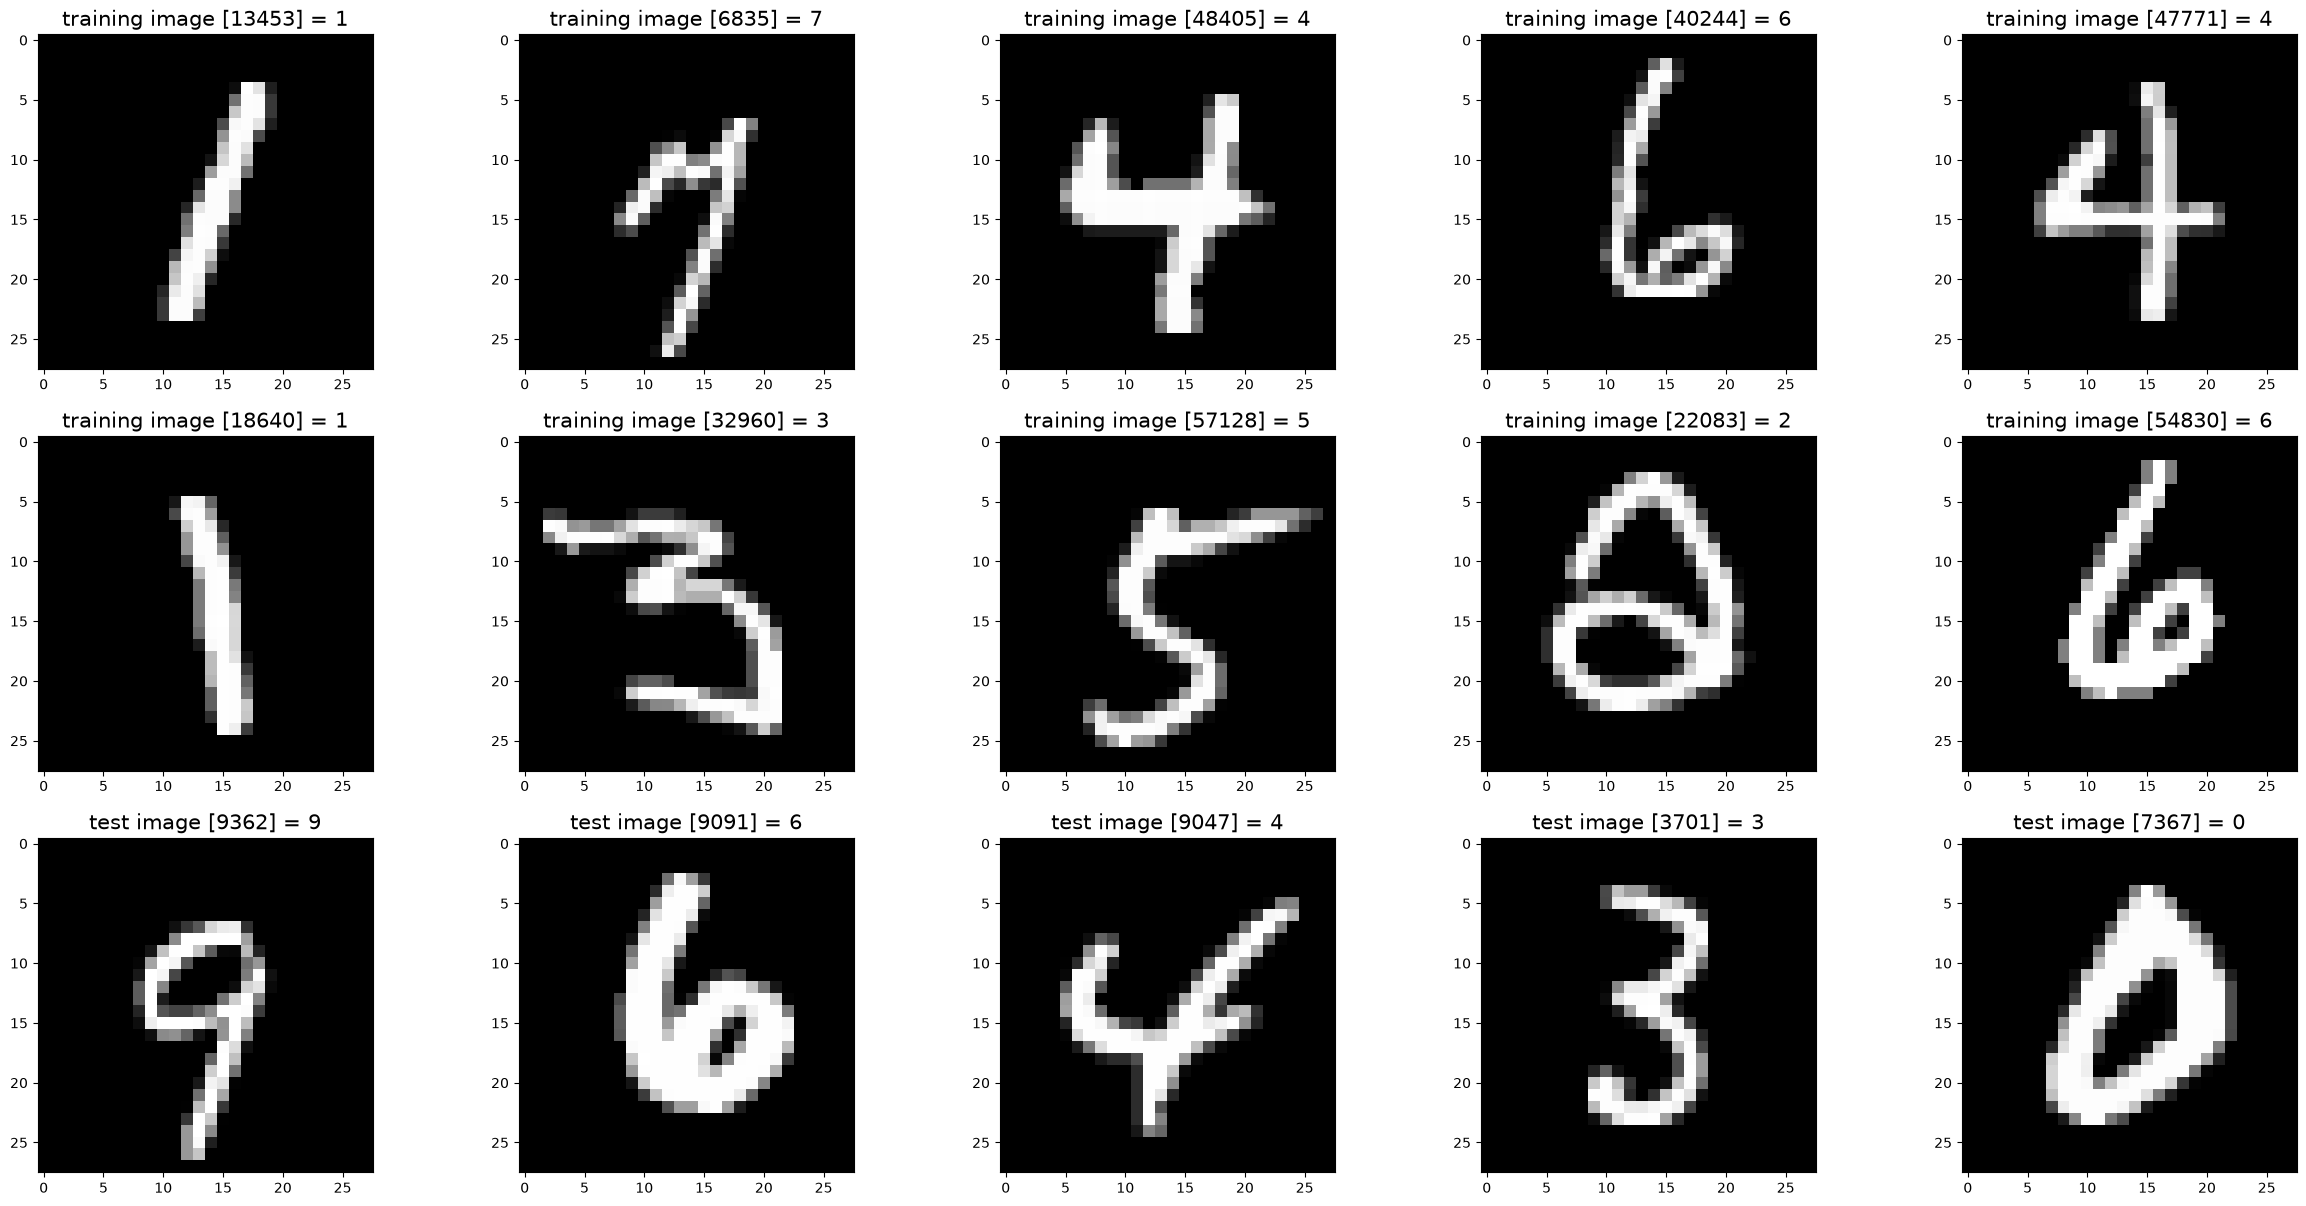

In [4]:
%matplotlib inline
import random
import matplotlib.pyplot as plt

#
# Set file paths based on added MNIST Datasets
#
input_path = ''
training_images_filepath = join(input_path, 'train-images-idx3-ubyte/train-images-idx3-ubyte')
training_labels_filepath = join(input_path, 'train-labels-idx1-ubyte/train-labels-idx1-ubyte')
test_images_filepath = join(input_path, 't10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
test_labels_filepath = join(input_path, 't10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')

#
# Helper function to show a list of images with their relating titles
#
def show_images(images, title_texts):
    cols = 5
    rows = int(len(images)/cols) + 1
    plt.figure(figsize=(30,20))
    index = 1    
    for x in zip(images, title_texts):        
        image = x[0]        
        title_text = x[1]
        plt.subplot(rows, cols, index)        
        plt.imshow(image, cmap=plt.cm.gray)
        if (title_text != ''):
            plt.title(title_text, fontsize = 15);        
        index += 1

#
# Load MINST dataset
#
mnist_dataloader = MnistDataloader(training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath)
(x_train, y_train), (x_test, y_test) = mnist_dataloader.load_data()

#
# Show some random training and test images 
#
images_2_show = []
titles_2_show = []
for i in range(0, 10):
    r = random.randint(1, 60000)
    images_2_show.append(x_train[r])
    titles_2_show.append('training image [' + str(r) + '] = ' + str(y_train[r]))    

for i in range(0, 5):
    r = random.randint(1, 10000)
    images_2_show.append(x_test[r])        
    titles_2_show.append('test image [' + str(r) + '] = ' + str(y_test[r]))    

show_images(images_2_show, titles_2_show)

0.738475844190692
0.014787265448324139
0.002903448448710529
0.0010802966519774771
0.0004988553052517254
0.00025491230139935707
0.00013745978663986277
7.654058267473441e-05
4.3463354965024334e-05
2.499478286124569e-05


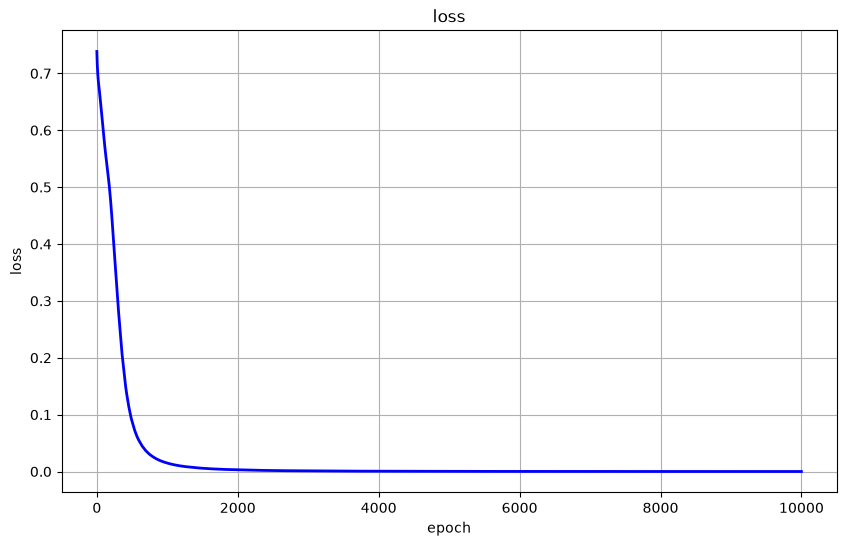

In [5]:
rng = np.random.default_rng(42)
layers = [
    Layer(num_neurons=4, num_input_connections=2, activation_function=ReLU(), rng=rng, alpha=0.005),
    Layer(num_neurons=2, num_input_connections=4, activation_function=Softmax(), rng=rng, alpha=0.005)
]

import matplotlib.pyplot as plt
loss_history = []
for i in range(10000):
    out = x
    for layer in layers:
        out = layer.forward(out)

    eps = 1e-15
    out = np.clip(out, eps, 1 - eps)
    loss = -np.sum(y * np.log(out)) / x.shape[0]
    loss_history.append(loss)

    if i % 1000 == 0:
        print(loss)

    upstream_error = out - y
    for layer in reversed(layers):
        upstream_error = layer.backward(upstream_error)

plt.figure(figsize=(10,6))
plt.plot(loss_history, color='blue', linewidth=2)
plt.title('loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.grid(True)
plt.show()


In [6]:
out = x
for layer in layers:
    out = layer.forward(out)
print(out)


[[1.18122485e-05 9.99988188e-01]
 [9.99967375e-01 3.26250208e-05]
 [9.99993396e-01 6.60370297e-06]
 [6.93998203e-06 9.99993060e-01]]
